# Wine Quality Prediction using Multiple Linear Regression

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Dataset

In [2]:
df = pd.read_csv("winequality-red.csv", sep=";")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Understand the Dataset

In [3]:
print(df.info())
print("\nDescriptive Statistics:")
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Descriptive Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 4. Check Missing Values

In [4]:
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## 5. Check and Remove Duplicate Records

In [5]:
print("Duplicate Records:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)


Duplicate Records: 240
Shape after removing duplicates: (1359, 12)


## 6. Outlier Detection using IQR

In [6]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()

print("Potential Outliers:")
print(outliers)


Potential Outliers:
fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
quality                  27
dtype: int64


## 7. Boxplot

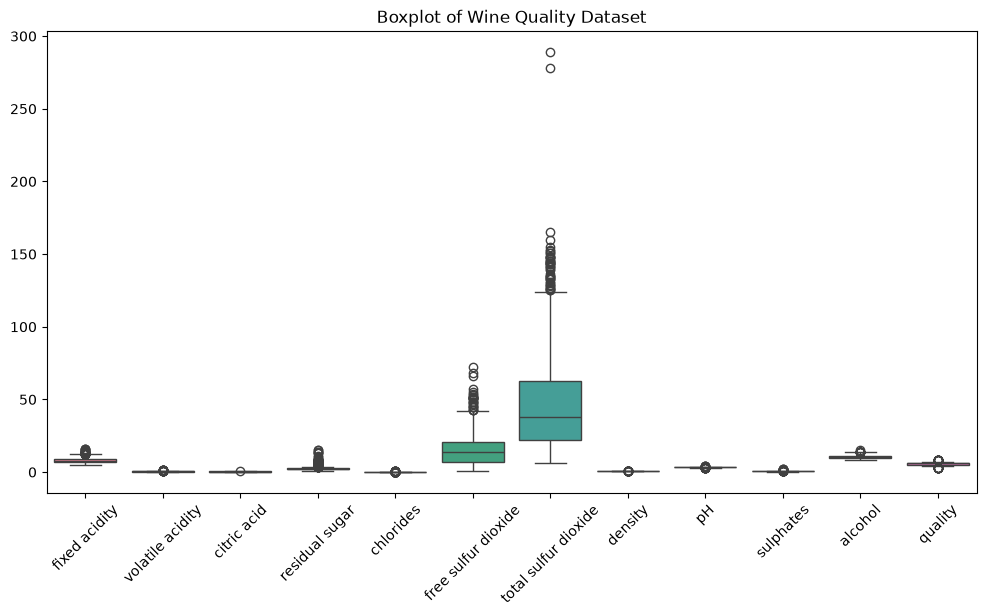

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of Wine Quality Dataset")
plt.show()


## 8. Exploratory Data Analysis

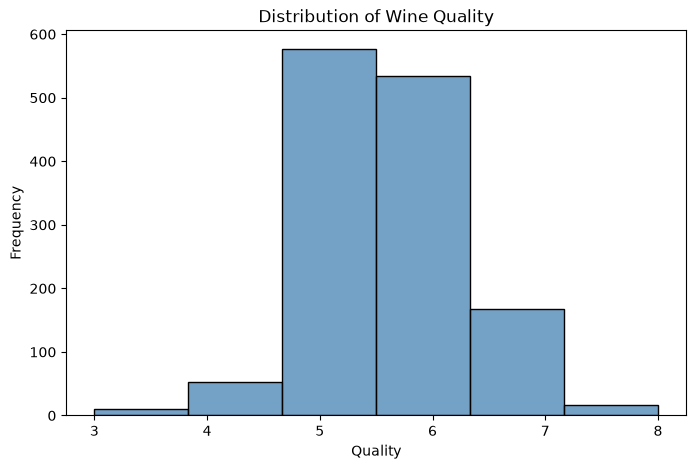

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["quality"], bins=6, color="steelblue")
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()


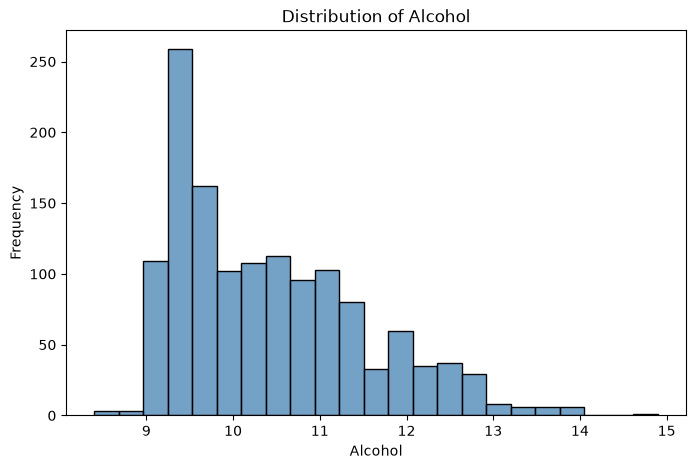

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["alcohol"], color="steelblue")
plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()


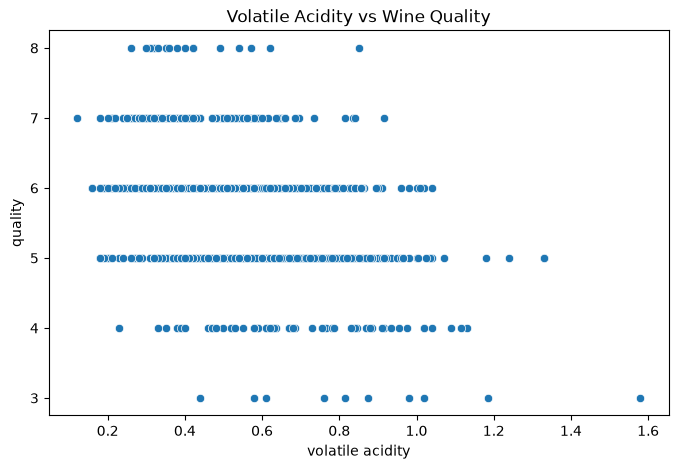

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="volatile acidity", y="quality")
plt.title("Volatile Acidity vs Wine Quality")
plt.show()


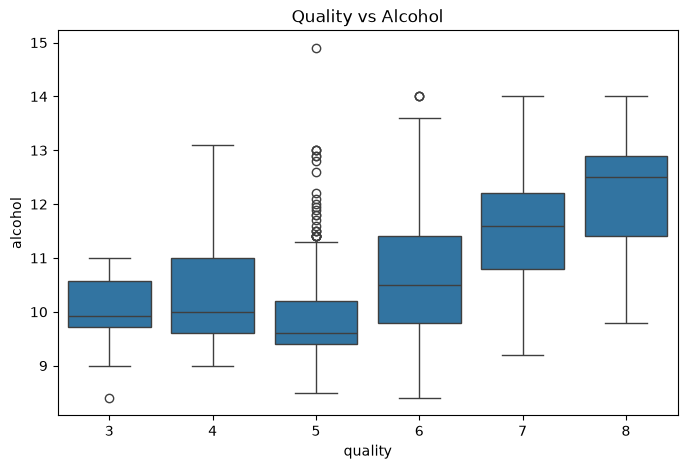

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Quality vs Alcohol")
plt.show()


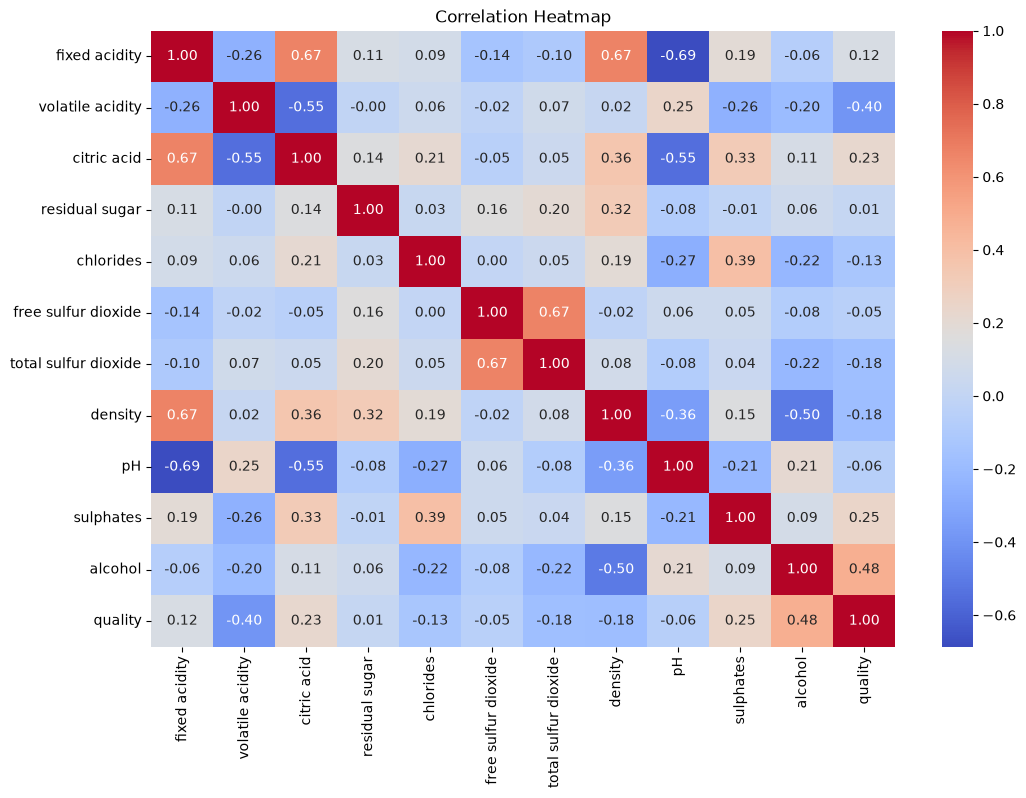

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


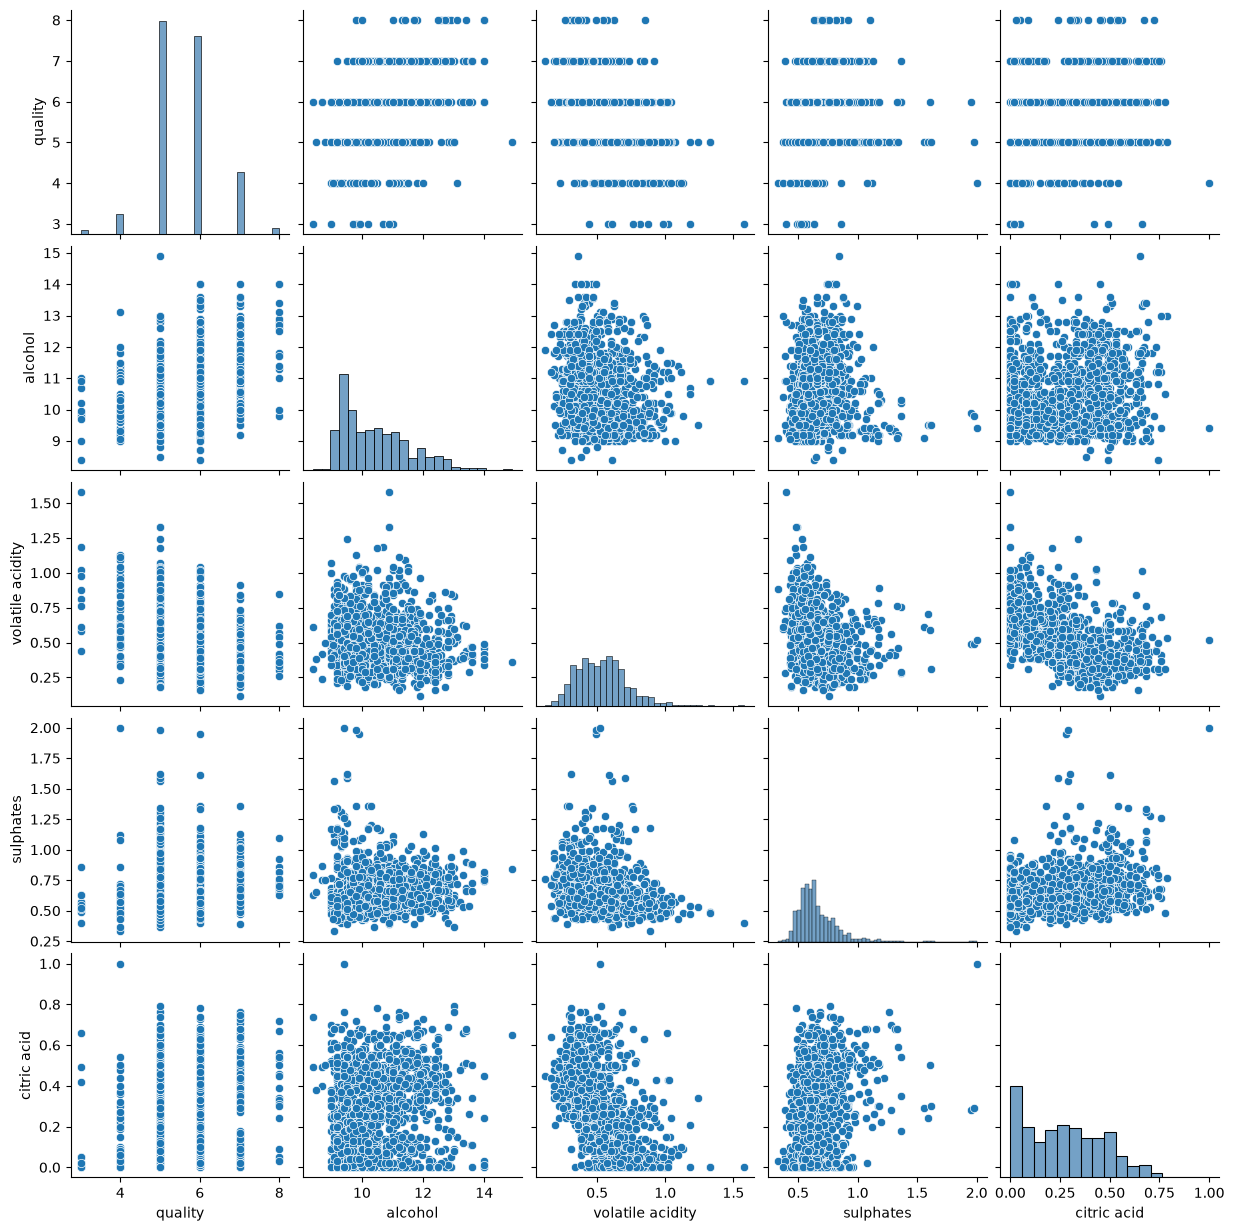

In [13]:
sns.pairplot(df[["quality", "alcohol", "volatile acidity", "sulphates", "citric acid"]], diag_kws={"color": "steelblue"})
plt.show()


## 9. Separate Predictors and Target

In [14]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("Predictor Variables:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)


Predictor Variables:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

Target Variable:
quality


## 10. Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (1087, 11)
Testing Data: (272, 11)


## 11. Original Multiple Linear Regression

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
k = X_test.shape[1]
adjusted_r2 = 1 - (1-r2) * (n-1) / (n-k-1)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)


MAE: 0.5041409053480704
MSE: 0.43100900509009576
RMSE: 0.6565127607976069
R²: 0.3915360499058209
Adjusted R²: 0.3657933443249133


## 12. Standardization using StandardScaler

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standard_model = LinearRegression()
standard_model.fit(X_train_scaled, y_train)

y_pred_std = standard_model.predict(X_test_scaled)

mae_std = mean_absolute_error(y_test, y_pred_std)
mse_std = mean_squared_error(y_test, y_pred_std)
rmse_std = np.sqrt(mse_std)
r2_std = r2_score(y_test, y_pred_std)

adjusted_r2_std = 1 - (1-r2_std) * (n-1) / (n-k-1)

print("MAE:", mae_std)
print("MSE:", mse_std)
print("RMSE:", rmse_std)
print("R²:", r2_std)
print("Adjusted R²:", adjusted_r2_std)


MAE: 0.5041409053480713
MSE: 0.4310090050900972
RMSE: 0.656512760797608
R²: 0.3915360499058189
Adjusted R²: 0.3657933443249112


## 13. Normalization using MinMaxScaler

In [18]:
minmax = MinMaxScaler()

X_train_normalized = minmax.fit_transform(X_train)
X_test_normalized = minmax.transform(X_test)

normalized_model = LinearRegression()
normalized_model.fit(X_train_normalized, y_train)

y_pred_norm = normalized_model.predict(X_test_normalized)

mae_norm = mean_absolute_error(y_test, y_pred_norm)
mse_norm = mean_squared_error(y_test, y_pred_norm)
rmse_norm = np.sqrt(mse_norm)
r2_norm = r2_score(y_test, y_pred_norm)

adjusted_r2_norm = 1 - (1-r2_norm) * (n-1) / (n-k-1)

print("MAE:", mae_norm)
print("MSE:", mse_norm)
print("RMSE:", rmse_norm)
print("R²:", r2_norm)
print("Adjusted R²:", adjusted_r2_norm)


MAE: 0.5041409053480712
MSE: 0.4310090050900972
RMSE: 0.656512760797608
R²: 0.3915360499058189
Adjusted R²: 0.3657933443249112


## 14. Compare Original, Standardized and Normalized Models

In [19]:
comparison = pd.DataFrame({
    "Model": ["Original", "StandardScaler", "MinMaxScaler"],
    "MAE": [mae, mae_std, mae_norm],
    "MSE": [mse, mse_std, mse_norm],
    "RMSE": [rmse, rmse_std, rmse_norm],
    "R²": [r2, r2_std, r2_norm],
    "Adjusted R²": [adjusted_r2, adjusted_r2_std, adjusted_r2_norm]
})

comparison


,Model,MAE,MSE,RMSE,R²,Adjusted R²
0,Original,0.504141,0.431009,0.656513,0.391536,0.365793
1,StandardScaler,0.504141,0.431009,0.656513,0.391536,0.365793
2,MinMaxScaler,0.504141,0.431009,0.656513,0.391536,0.365793


## 15. Feature Selection Test 1 - Alcohol and Volatile Acidity

In [20]:
X1 = df[["alcohol", "volatile acidity"]]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size=0.2, random_state=42
)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)
y1_pred = model1.predict(X1_test)

mae1 = mean_absolute_error(y1_test, y1_pred)
mse1 = mean_squared_error(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)
r21 = r2_score(y1_test, y1_pred)
adj_r21 = 1 - (1-r21) * (len(y1_test)-1) / (len(y1_test)-X1.shape[1]-1)

print("R²:", r21)
print("Adjusted R²:", adj_r21)
print("RMSE:", rmse1)
print("MAE:", mae1)


R²: 0.38991378992431447
Adjusted R²: 0.38537783297207884
RMSE: 0.6573873610403672
MAE: 0.5149625538934368


## 16. Feature Selection Test 2 - Alcohol, Volatile Acidity and Sulphates

In [21]:
X2 = df[["alcohol", "volatile acidity", "sulphates"]]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
mse2 = mean_squared_error(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y2_test, y2_pred)
adj_r22 = 1 - (1-r22) * (len(y2_test)-1) / (len(y2_test)-X2.shape[1]-1)

print("R²:", r22)
print("Adjusted R²:", adj_r22)
print("RMSE:", rmse2)
print("MAE:", mae2)


R²: 0.41513967740940694
Adjusted R²: 0.40859273349981073
RMSE: 0.6436530410194005
MAE: 0.4982068271544365


## 17. Feature Selection Test 3 - Alcohol, Volatile Acidity, Sulphates and Chlorides

In [22]:
X3 = df[["alcohol", "volatile acidity", "sulphates", "chlorides"]]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)

mae3 = mean_absolute_error(y3_test, y3_pred)
mse3 = mean_squared_error(y3_test, y3_pred)
rmse3 = np.sqrt(mse3)
r23 = r2_score(y3_test, y3_pred)
adj_r23 = 1 - (1-r23) * (len(y3_test)-1) / (len(y3_test)-X3.shape[1]-1)

print("R²:", r23)
print("Adjusted R²:", adj_r23)
print("RMSE:", rmse3)
print("MAE:", mae3)


R²: 0.4184873435088984
Adjusted R²: 0.40977554341165345
RMSE: 0.6418083033992248
MAE: 0.49450005778149814


## 18. Feature Selection Test 4 - Six Selected Variables

In [23]:
X4 = df[["fixed acidity", "volatile acidity", "chlorides", "density", "sulphates", "alcohol"]]

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y, test_size=0.2, random_state=42
)

model4 = LinearRegression()
model4.fit(X4_train, y4_train)
y4_pred = model4.predict(X4_test)

mae4 = mean_absolute_error(y4_test, y4_pred)
mse4 = mean_squared_error(y4_test, y4_pred)
rmse4 = np.sqrt(mse4)
r24 = r2_score(y4_test, y4_pred)
adj_r24 = 1 - (1-r24) * (len(y4_test)-1) / (len(y4_test)-X4.shape[1]-1)

print("R²:", r24)
print("Adjusted R²:", adj_r24)
print("RMSE:", rmse4)
print("MAE:", mae4)


R²: 0.42021403366325494
Adjusted R²: 0.4070868042367626
RMSE: 0.6408547317619602
MAE: 0.49298521855590327


## 19. Feature Selection Comparison

In [24]:
feature_comparison = pd.DataFrame({
    "Variables": [
        "All 11 variables",
        "Alcohol + Volatile Acidity",
        "Alcohol + Volatile Acidity + Sulphates",
        "Alcohol + Volatile Acidity + Sulphates + Chlorides",
        "Fixed Acidity + Volatile Acidity + Chlorides + Density + Sulphates + Alcohol"
    ],
    "R²": [r2, r21, r22, r23, r24],
    "Adjusted R²": [adjusted_r2, adj_r21, adj_r22, adj_r23, adj_r24],
    "RMSE": [rmse, rmse1, rmse2, rmse3, rmse4],
    "MAE": [mae, mae1, mae2, mae3, mae4]
})

feature_comparison


,Variables,R²,Adjusted R²,RMSE,MAE
0,All 11 variables,0.391536,0.365793,0.656513,0.504141
1,Alcohol + Volatile Acidity,0.389914,0.385378,0.657387,0.514963
2,Alcohol + Volatile Acidity + Sulphates,0.415140,0.408593,0.643653,0.498207
3,Alcohol + Volatile Acidity + Sulphates + Chlor...,0.418487,0.409776,0.641808,0.494500
4,Fixed Acidity + Volatile Acidity + Chlorides +...,0.420214,0.407087,0.640855,0.492985


## 20. Final Model

In [25]:
final_model = model4
final_X_test = X4_test
final_y_test = y4_test
final_y_pred = y4_pred

print("Final Model: Fixed Acidity, Volatile Acidity, Chlorides, Density, Sulphates and Alcohol")
print("MAE:", mae4)
print("MSE:", mse4)
print("RMSE:", rmse4)
print("R²:", r24)
print("Adjusted R²:", adj_r24)


Final Model: Fixed Acidity, Volatile Acidity, Chlorides, Density, Sulphates and Alcohol
MAE: 0.49298521855590327
MSE: 0.41069478722169395
RMSE: 0.6408547317619602
R²: 0.42021403366325494
Adjusted R²: 0.4070868042367626


## 21. Actual vs Predicted Values

In [26]:
actual_vs_predicted = pd.DataFrame({
    "Actual Quality": final_y_test.values,
    "Predicted Quality": final_y_pred
})

actual_vs_predicted.head(10)


,Actual Quality,Predicted Quality
0,5,5.131370
1,6,5.764951
2,7,6.215713
3,5,5.192718
4,4,5.226119
5,7,6.795697
6,5,5.623166
7,5,4.891235
8,6,5.798735
9,5,5.517733


## 22. Actual vs Predicted Graph

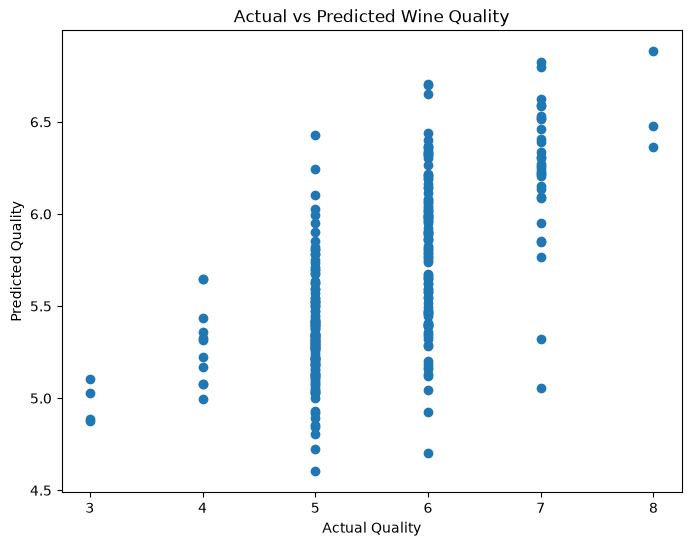

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(final_y_test, final_y_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()


## 23. Model Coefficients and Intercept

In [28]:
coefficient_table = pd.DataFrame({
    "Feature": X4.columns,
    "Coefficient": final_model.coef_
})

print("Model Intercept:", final_model.intercept_)
coefficient_table


Model Intercept: 25.408894920411875


,Feature,Coefficient
0,fixed acidity,0.046374
1,volatile acidity,-1.017594
2,chlorides,-1.778133
3,density,-22.977211
4,sulphates,0.850675
5,alcohol,0.275945


## 24. Prediction

In [29]:
sample_data = X4.iloc[[0]]
prediction = final_model.predict(sample_data)

print("Predicted Wine Quality:", prediction[0])


Predicted Wine Quality: 5.048201275623686


## 25. Final Model Summary

In [30]:
print("=" * 50)
print("WINE QUALITY PREDICTION - MULTIPLE LINEAR REGRESSION")
print("=" * 50)
print("Original observations:", 1599)
print("Duplicate records removed:", 240)
print("Final observations:", len(df))
print("Training samples:", X4_train.shape[0])
print("Testing samples:", X4_test.shape[0])
print("Final predictors:", X4.columns.tolist())
print("R²:", r24)
print("Adjusted R²:", adj_r24)
print("RMSE:", rmse4)
print("MAE:", mae4)


WINE QUALITY PREDICTION - MULTIPLE LINEAR REGRESSION
Original observations: 1599
Duplicate records removed: 240
Final observations: 1359
Training samples: 1087
Testing samples: 272
Final predictors: ['fixed acidity', 'volatile acidity', 'chlorides', 'density', 'sulphates', 'alcohol']
R²: 0.42021403366325494
Adjusted R²: 0.4070868042367626
RMSE: 0.6408547317619602
MAE: 0.49298521855590327
